# Cluster Analysis in Finance

Official sector labels (GICS, ICB) group companies by what they *do*; they don't necessarily group them by how their stock prices actually move together. This notebook builds a stock universe where the true, latent statistical structure deliberately cuts across nominal sector boundaries (a "rate-sensitive" cluster spanning parts of Financials and Industrials, a "growth" cluster spanning parts of Tech, Consumer Discretionary, and Healthcare), then asks whether unsupervised clustering can recover that hidden structure from returns alone, and whether doing so is actually useful: for diversification, and for finding pairs-trading opportunities a sector-based screen would never surface.

90 stocks, 10 years of monthly returns, labeled with a nominal sector (Tech, Financials, Healthcare, Energy, Consumer Discretionary, Industrials) that an investor would actually see, but driven by 5 true latent clusters that only partially align with those labels, each with its own common return factor, deliberately assigned so that, for example, some Tech and some Consumer Discretionary and some Healthcare names share a genuine "growth" factor, while a "commodity-linked" cluster spans Energy and Industrials.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.decomposition import PCA

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (7, 4.2), 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'grid.alpha': 0.35,
})

rng = np.random.default_rng(303)

n_stocks = 90
n_months = 10 * 12
dates = pd.date_range('2015-01-31', periods=n_months, freq='ME')

nominal_sectors = ['Tech', 'Financials', 'Healthcare', 'Energy', 'Cons_Disc', 'Industrials']
stock_nominal_sector = np.repeat(nominal_sectors, n_stocks // len(nominal_sectors))

n_true_clusters = 5
cluster_names = ['Growth/Tech-like', 'Rate-Sensitive', 'Defensive/Health', 'Cyclical/Consumer', 'Commodity-linked']
cluster_probs = {
    'Tech':        [0.55, 0.05, 0.05, 0.30, 0.05],
    'Financials':  [0.05, 0.60, 0.05, 0.05, 0.25],
    'Healthcare':  [0.30, 0.05, 0.55, 0.05, 0.05],
    'Energy':      [0.05, 0.10, 0.05, 0.10, 0.70],
    'Cons_Disc':   [0.35, 0.05, 0.05, 0.50, 0.05],
    'Industrials': [0.10, 0.30, 0.10, 0.10, 0.40],
}
true_cluster = np.array([rng.choice(n_true_clusters, p=cluster_probs[s]) for s in stock_nominal_sector])

cluster_factor = rng.normal(0.8, 5.0, (n_months, n_true_clusters))
market_factor = rng.normal(0.6, 3.5, n_months)
idio_vol = rng.uniform(5.0, 9.0, n_stocks)
loading = rng.uniform(0.5, 0.85, n_stocks)

returns = np.zeros((n_months, n_stocks))
for t in range(n_months):
    returns[t] = market_factor[t] + loading * cluster_factor[t, true_cluster] + rng.normal(0, idio_vol)

stock_ids = [f"S{i+1}_{stock_nominal_sector[i]}" for i in range(n_stocks)]
ret_df = pd.DataFrame(returns, index=dates, columns=stock_ids)
nominal_map = pd.Series(stock_nominal_sector, index=stock_ids)
true_cluster_map = pd.Series([cluster_names[c] for c in true_cluster], index=stock_ids)

print(f"Universe: {n_stocks} stocks, {n_months} months, {n_true_clusters} true latent clusters")
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', None)
print("\nCross-tab, nominal sector vs. true cluster (the mismatch is the whole point):")
print(pd.crosstab(nominal_map, true_cluster_map))

Universe: 90 stocks, 120 months, 5 true latent clusters

Cross-tab, nominal sector vs. true cluster (the mismatch is the whole point):
col_0        Commodity-linked  Cyclical/Consumer  Defensive/Health  Growth/Tech-like  Rate-Sensitive
row_0                                                                                               
Cons_Disc                   0                  8                 0                 5               2
Energy                      8                  1                 0                 3               3
Financials                  1                  0                 0                 2              12
Healthcare                  0                  1                12                 1               1
Industrials                 7                  2                 1                 1               4
Tech                        0                  5                 0                 9               1


## 2. Distance Metrics and Features for Clustering Returns

Clustering needs a notion of "distance" between stocks. The standard finance convention converts correlation into a proper metric distance:

$$d_{ij} = \sqrt{\tfrac12(1 - \rho_{ij})}$$

which ranges from 0 (perfectly correlated, $\rho=1$) to 1 (perfectly anti-correlated, $\rho=-1$), and satisfies the triangle inequality, unlike $1-\rho$ or $-\rho$ directly. For K-means and Gaussian Mixture Models (which need actual coordinates, not just pairwise distances), each stock's standardized monthly return series is reduced to its top 5 principal components first, exactly the PCA machinery from earlier notebooks in this series, repurposed here as a feature-engineering step for clustering.

PCA feature variance explained (5 components): 27.1%


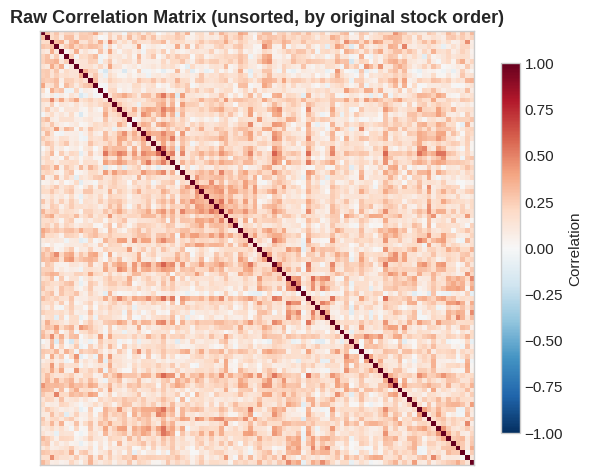

In [2]:
corr = ret_df.corr()
dist_vals = np.sqrt(0.5 * (1 - corr.values))
np.fill_diagonal(dist_vals, 0)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_title('Raw Correlation Matrix (unsorted, by original stock order)')
ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=ax, label='Correlation', shrink=0.8)
plt.show()

X = ret_df.T.values
X = (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True)
pca = PCA(n_components=5, random_state=0)
X_pca = pca.fit_transform(X)
print(f"PCA feature variance explained (5 components): {pca.explained_variance_ratio_.sum():.1%}")

## 3. Three Clustering Approaches

**Hierarchical (agglomerative) clustering** starts with every stock as its own cluster and repeatedly merges the closest pair, building a full tree (dendrogram) that can be cut at any desired number of clusters after the fact. The choice of **linkage** (how "distance between clusters" is defined from pairwise distances) matters: average and complete linkage are compared against **Ward's method** (which merges to minimize the increase in within-cluster variance at each step, generally the best-behaved choice for roughly compact, similarly-sized clusters, exactly this simulation's structure).

**K-means** partitions the PCA-reduced feature space directly into $k$ clusters by iteratively minimizing within-cluster variance around $k$ centroids, fast, but requires $k$ to be chosen in advance (Section 4) and assumes roughly spherical, similarly-sized clusters.

**Gaussian Mixture Models (GMM)** generalize K-means to *soft*, probabilistic assignment: each stock gets a probability of belonging to each cluster, rather than a single hard label, and clusters can have different shapes and sizes, useful when membership is genuinely ambiguous, as several stocks here (assigned to a cluster with only, say, 55% probability under the true simulation) actually are.

In [3]:
true_labels_int = pd.Categorical(true_cluster_map).codes

# --- Hierarchical clustering: compare linkage methods ---
condensed = squareform(dist_vals, checks=False)
linkage_results = {}
for method in ['average', 'complete', 'ward']:
    Z = linkage(condensed, method=method)
    labels = fcluster(Z, t=5, criterion='maxclust')
    ari = adjusted_rand_score(true_labels_int, labels)
    linkage_results[method] = (Z, labels, ari)
    print(f"Hierarchical ({method:<8} linkage): ARI vs. true clusters = {ari:.4f}")

Z_ward, hier_labels, ari_ward = linkage_results['ward']

# --- K-means ---
km = KMeans(n_clusters=5, n_init=20, random_state=0).fit(X_pca)
ari_km = adjusted_rand_score(true_labels_int, km.labels_)
print(f"\nK-means:                        ARI vs. true clusters = {ari_km:.4f}")

# --- GMM ---
gmm = GaussianMixture(n_components=5, n_init=10, random_state=0).fit(X_pca)
gmm_labels = gmm.predict(X_pca)
ari_gmm = adjusted_rand_score(true_labels_int, gmm_labels)
print(f"Gaussian Mixture Model:         ARI vs. true clusters = {ari_gmm:.4f}")

# --- for comparison: how well do the NOMINAL sector labels themselves match the true clusters? ---
ari_nominal = adjusted_rand_score(true_labels_int, pd.Categorical(nominal_map).codes)
print(f"\n(Nominal sector labels alone:   ARI vs. true clusters = {ari_nominal:.4f} -- every clustering method above beats this)")

Hierarchical (average  linkage): ARI vs. true clusters = 0.7606
Hierarchical (complete linkage): ARI vs. true clusters = 0.7589
Hierarchical (ward     linkage): ARI vs. true clusters = 0.9147

K-means:                        ARI vs. true clusters = 1.0000
Gaussian Mixture Model:         ARI vs. true clusters = 1.0000

(Nominal sector labels alone:   ARI vs. true clusters = 0.2629 -- every clustering method above beats this)


**Diagram - the dendrogram, and the correlation matrix reordered by discovered cluster.** The dendrogram shows the full hierarchical merge structure (colored by the 5-cluster cut); reordering the correlation heatmap by that same cluster assignment turns the formless matrix from Section 2 into unmistakable diagonal blocks, exactly the hidden structure the raw, sector-ordered heatmap couldn't show.

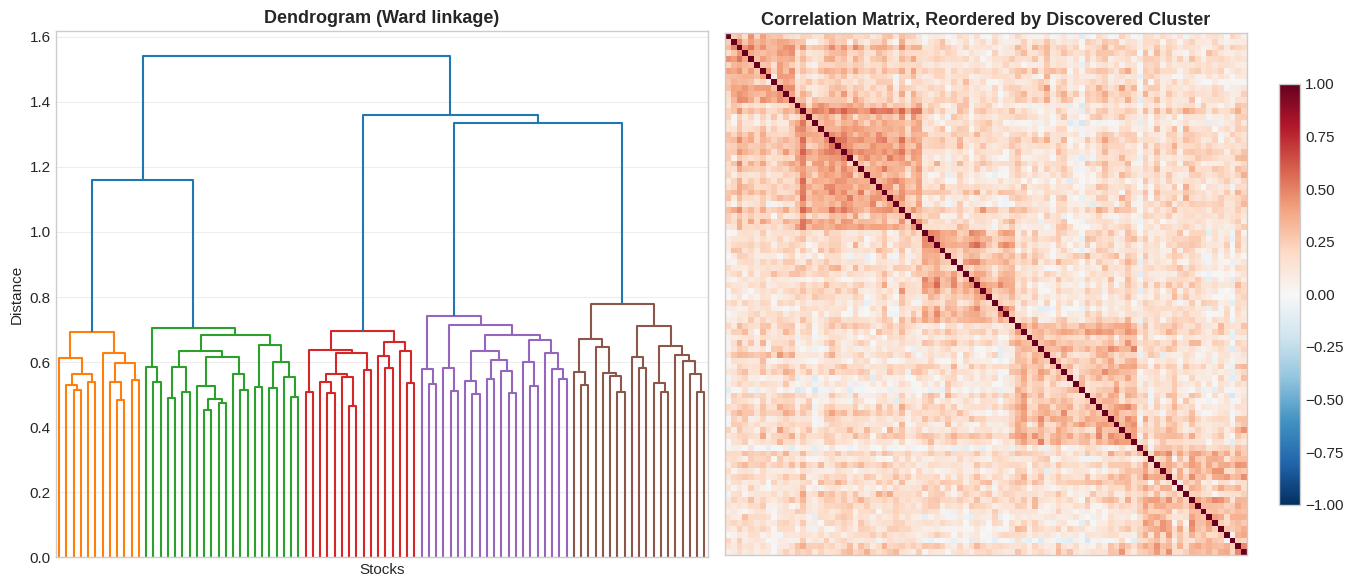

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

dendrogram(Z_ward, ax=axes[0], color_threshold=Z_ward[-4, 2], labels=None, no_labels=True)
axes[0].set_title("Dendrogram (Ward linkage)")
axes[0].set_xlabel('Stocks'); axes[0].set_ylabel('Distance')

order = np.argsort(hier_labels)
sorted_corr = corr.values[np.ix_(order, order)]
im = axes[1].imshow(sorted_corr, cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_title('Correlation Matrix, Reordered by Discovered Cluster')
axes[1].set_xticks([]); axes[1].set_yticks([])
fig.colorbar(im, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

**Diagram - PCA-projected scatter, colored by true cluster vs. K-means assignment.** The two panels are visually almost identical, direct confirmation that K-means recovered the true structure from the data alone.

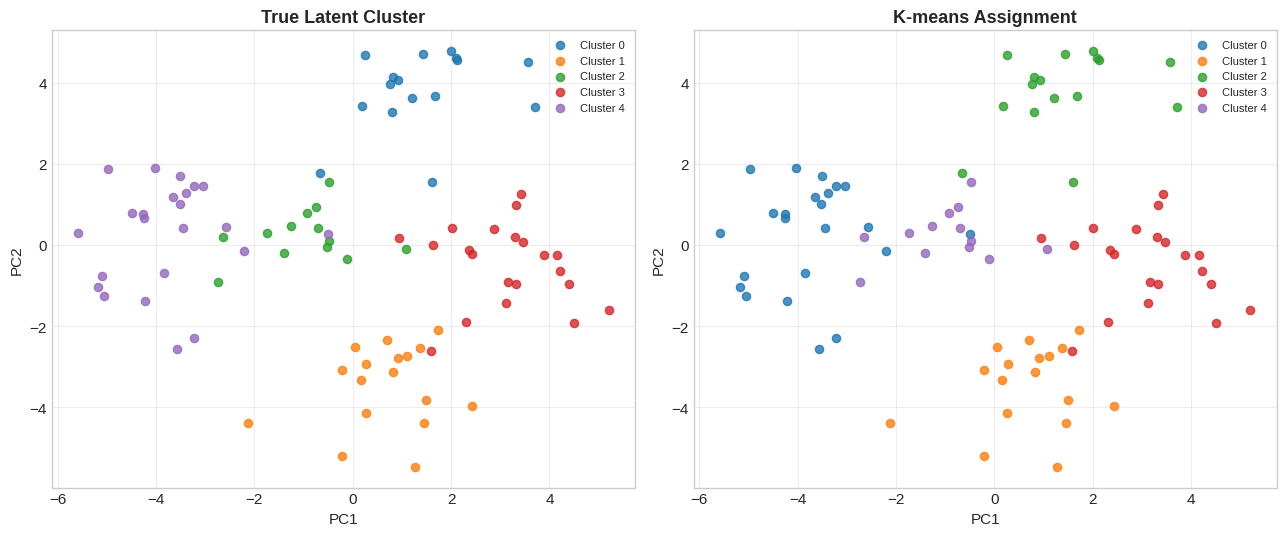

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
cmap = plt.cm.tab10

for ax, labels, title in [(axes[0], true_labels_int, 'True Latent Cluster'), (axes[1], km.labels_, 'K-means Assignment')]:
    for lbl in np.unique(labels):
        mask = labels == lbl
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=35, color=cmap(lbl % 10), alpha=0.8, label=f'Cluster {lbl}')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4. How Many Clusters? The Elbow Method and Silhouette Score

Every method above was told $k=5$ in advance, cheating slightly, since the true number of clusters is normally unknown. Two standard diagnostics for choosing $k$ without that knowledge: the **elbow method** (plot within-cluster inertia against $k$, look for where adding more clusters stops helping much) and the **silhouette score** (a direct measure, from $-1$ to $1$, of how well-separated the clusters are, maximized at the "right" $k$).

In [6]:
inertias, sil_scores = [], []
k_range = range(2, 12)
for k in k_range:
    km_k = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X_pca)
    inertias.append(km_k.inertia_)
    sil_scores.append(silhouette_score(X_pca, km_k.labels_))

best_k = list(k_range)[np.argmax(sil_scores)]
print(f"Silhouette-selected k = {best_k}  (the true simulated number of clusters is 5)")

Silhouette-selected k = 5  (the true simulated number of clusters is 5)


**Diagram - elbow curve and silhouette score.** The elbow is visually suggestive but genuinely ambiguous (a common, honest limitation of the method); the silhouette score peaks unambiguously at the true $k=5$.

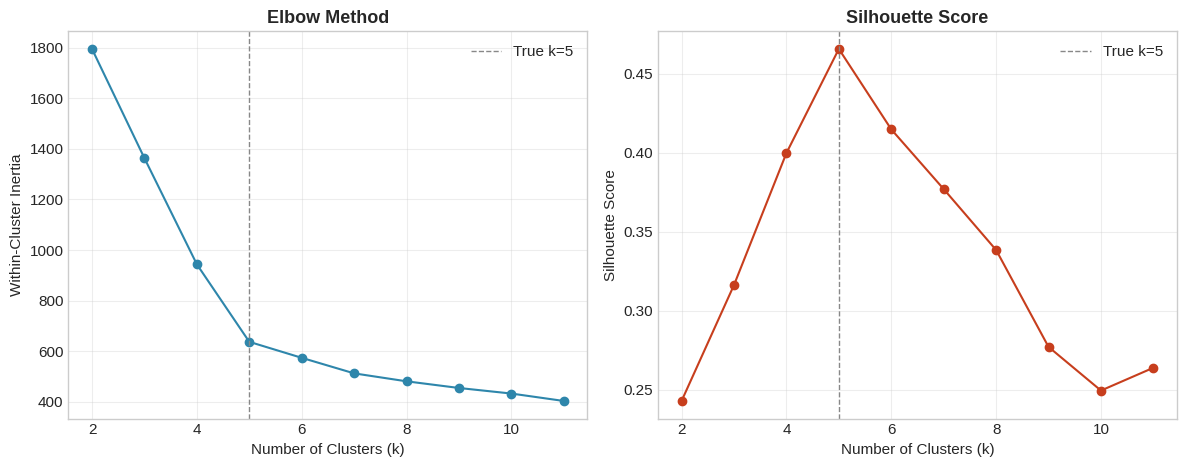

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].plot(list(k_range), inertias, 'o-', color='#2E86AB')
axes[0].axvline(5, color='#888888', linestyle='--', linewidth=1, label='True k=5')
axes[0].set_xlabel('Number of Clusters (k)'); axes[0].set_ylabel('Within-Cluster Inertia')
axes[0].set_title('Elbow Method'); axes[0].legend()

axes[1].plot(list(k_range), sil_scores, 'o-', color='#C73E1D')
axes[1].axvline(5, color='#888888', linestyle='--', linewidth=1, label='True k=5')
axes[1].set_xlabel('Number of Clusters (k)'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score'); axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Application 1: Cluster-Based Portfolio Diversification

A portfolio built from stocks that are all highly correlated with each other isn't really diversified, no matter how many names it holds or how many different sector labels those names carry. This section builds three 5-stock, equal-weighted portfolios many times over and compares their realized volatility: a **naive random** selection (no diversification logic at all), a portfolio diversified by **nominal sector** (one stock per nominal sector, the standard retail approach), and a portfolio diversified by **true statistical cluster** (one stock per cluster, using the K-means assignment from Section 3).

In [8]:
def portfolio_vol(stocks, ret_df):
    w = np.full(len(stocks), 1 / len(stocks))
    cov = ret_df[stocks].cov().values
    return np.sqrt(w @ cov @ w) * np.sqrt(12)

cluster_assignment = pd.Series(km.labels_, index=ret_df.columns)
rng2 = np.random.default_rng(1)
n_trials = 500

random_vols, sector_div_vols, cluster_div_vols = [], [], []
for _ in range(n_trials):
    picks = rng2.choice(ret_df.columns, 5, replace=False)
    random_vols.append(portfolio_vol(picks, ret_df))

    chosen_sectors = rng2.choice(nominal_map.unique(), 5, replace=False)
    picks = [rng2.choice(nominal_map[nominal_map == s].index) for s in chosen_sectors]
    sector_div_vols.append(portfolio_vol(picks, ret_df))

    picks = [rng2.choice(cluster_assignment[cluster_assignment == c].index) for c in range(5)]
    cluster_div_vols.append(portfolio_vol(picks, ret_df))

print(f"Naive random 5-stock portfolio:              mean annualized vol = {np.mean(random_vols):.2f}%")
print(f"Nominal-sector-diversified portfolio:         mean annualized vol = {np.mean(sector_div_vols):.2f}%")
print(f"Statistical-cluster-diversified portfolio:    mean annualized vol = {np.mean(cluster_div_vols):.2f}%")

Naive random 5-stock portfolio:              mean annualized vol = 17.14%
Nominal-sector-diversified portfolio:         mean annualized vol = 16.99%
Statistical-cluster-diversified portfolio:    mean annualized vol = 16.31%


**Diagram - the distribution of realized portfolio volatility across all 500 trials, by strategy.** The cluster-diversified distribution sits visibly to the left of the other two, a real, if modest, reduction in risk purely from choosing names that don't already move together.

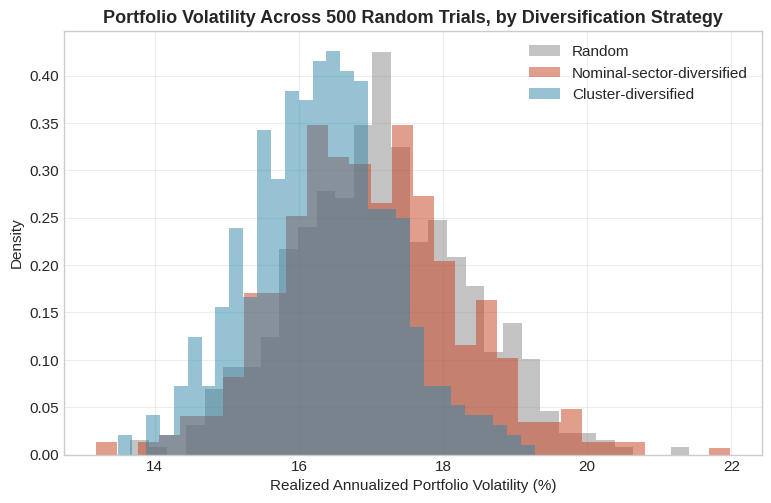

In [9]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.hist(random_vols, bins=30, alpha=0.5, color='#888888', label='Random', density=True)
ax.hist(sector_div_vols, bins=30, alpha=0.5, color='#C73E1D', label='Nominal-sector-diversified', density=True)
ax.hist(cluster_div_vols, bins=30, alpha=0.5, color='#2E86AB', label='Cluster-diversified', density=True)
ax.set_xlabel('Realized Annualized Portfolio Volatility (%)'); ax.set_ylabel('Density')
ax.set_title('Portfolio Volatility Across 500 Random Trials, by Diversification Strategy')
ax.legend()
plt.show()

## 6. Application 2: Pairs Trading Within a Cluster

Classic pairs trading needs two stocks that move together closely enough for their price spread to be genuinely mean-reverting. Screening for candidate pairs *within the same nominal sector* is the conventional approach, but it misses exactly the opportunities this notebook was built to find: two stocks in *different* nominal sectors that the clustering has identified as sharing the same true underlying driver.

In [10]:
largest_cluster = cluster_assignment.value_counts().idxmax()
members = cluster_assignment[cluster_assignment == largest_cluster].index

sub_corr_vals = ret_df[members].corr().values.copy()
np.fill_diagonal(sub_corr_vals, 0)
max_pair = np.unravel_index(np.argmax(sub_corr_vals), sub_corr_vals.shape)
stock_a, stock_b = members[max_pair[0]], members[max_pair[1]]

print(f"Largest cluster ({largest_cluster}, {len(members)} members)")
print(f"Most correlated pair within it: {stock_a}  &  {stock_b}   (correlation = {sub_corr_vals[max_pair]:.3f})")
print(f"Nominal sectors: {nominal_map[stock_a]}  vs.  {nominal_map[stock_b]}"
      f"{' -- a genuinely cross-sector pair a sector-based screen would never surface' if nominal_map[stock_a] != nominal_map[stock_b] else ''}")

log_price_a = np.cumsum(np.log(1 + ret_df[stock_a] / 100))
log_price_b = np.cumsum(np.log(1 + ret_df[stock_b] / 100))
spread = log_price_a - log_price_b
spread_z = (spread - spread.rolling(12).mean()) / spread.rolling(12).std()

position = pd.Series(0.0, index=spread.index)
current_pos = 0
for t in range(len(spread_z)):
    z = spread_z.iloc[t]
    if pd.isna(z):
        continue
    if current_pos == 0:
        if z > 1.5: current_pos = -1
        elif z < -1.5: current_pos = 1
    elif current_pos == 1 and z >= 0: current_pos = 0
    elif current_pos == -1 and z <= 0: current_pos = 0
    position.iloc[t] = current_pos

strategy_ret = position.shift(1) * spread.diff()
cum_strategy = strategy_ret.cumsum()
n_trades = int((position.diff().abs() > 0).sum() / 2)
print(f"\nCumulative pairs-trade P&L (log-spread units): {cum_strategy.iloc[-1]:.4f}")
print(f"Approximate number of round-trip trades: {n_trades}")

Largest cluster (0, 23 members)
Most correlated pair within it: S26_Financials  &  S49_Energy   (correlation = 0.588)
Nominal sectors: Financials  vs.  Energy -- a genuinely cross-sector pair a sector-based screen would never surface

Cumulative pairs-trade P&L (log-spread units): 0.0831
Approximate number of round-trip trades: 8


**Diagram - the spread, its z-score with entry/exit thresholds, and cumulative strategy P&L.** A textbook mean-reversion setup: the spread oscillates around its rolling mean, the strategy enters when it strays too far and exits when it reverts.

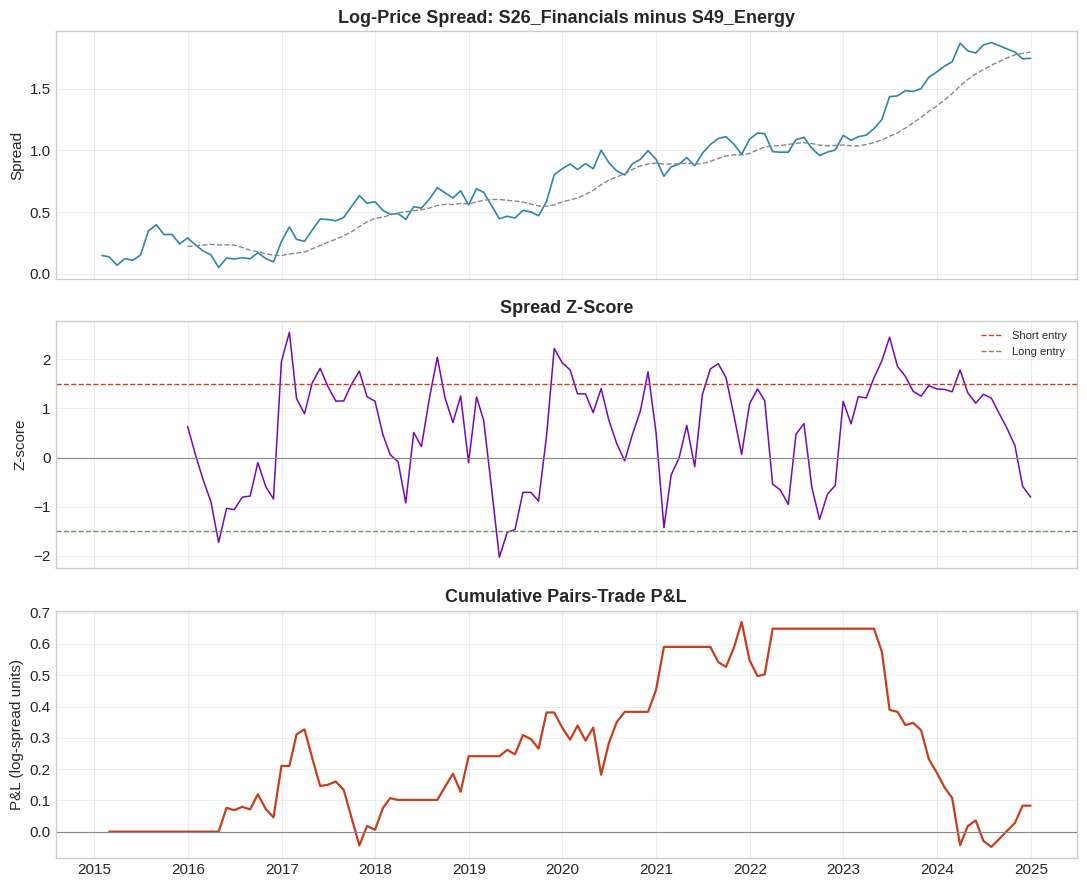

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

axes[0].plot(spread.index, spread, color='#2E86AB', linewidth=1.2)
axes[0].plot(spread.index, spread.rolling(12).mean(), color='#888888', linewidth=1, linestyle='--')
axes[0].set_title(f'Log-Price Spread: {stock_a} minus {stock_b}'); axes[0].set_ylabel('Spread')

axes[1].plot(spread_z.index, spread_z, color='#7209B7', linewidth=1.1)
axes[1].axhline(1.5, color='#C73E1D', linestyle='--', linewidth=1, label='Short entry')
axes[1].axhline(-1.5, color='#6A994E', linestyle='--', linewidth=1, label='Long entry')
axes[1].axhline(0, color='#888888', linewidth=0.8)
axes[1].set_title('Spread Z-Score'); axes[1].set_ylabel('Z-score'); axes[1].legend(fontsize=8)

axes[2].plot(cum_strategy.index, cum_strategy, color='#C73E1D', linewidth=1.6)
axes[2].axhline(0, color='#888888', linewidth=0.8)
axes[2].set_title('Cumulative Pairs-Trade P&L'); axes[2].set_ylabel('P&L (log-spread units)')

plt.tight_layout()
plt.show()